In [1]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import scipy.stats as st
import itertools
from matplotlib import gridspec


sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [95]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'cs_sweep'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


# run = '20251219-000823'
run = '20260129-111722'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [96]:
parsed_data = []

n_cs_arr = data['cs_arr'] 
K_std_arr = data['Kstd_arr'] 
csp_arr = data['csp_arr']
for i in range(args.N):
    N = data[f'N_final_{i}']
    C = data[f'C_{i}']
    n_cs = n_cs_arr[i]
    K_std = K_std_arr[i]
    csp = csp_arr[i]
    
    for j in range(args.iterations):
        richness = np.sum(N[:, j] > 1e-6)
        abundance = list(N[:, j])
        parsed_data.append([i, j, n_cs, K_std, csp, richness]+ abundance)

In [97]:
df = pd.DataFrame(parsed_data, columns = ['i', 'cs_j', 'n_cs', 'K_std', 'csp', 'richness', 'N1', 'N2', 'N3', 'N4'])

# Identify communities with high and low average richness

In [98]:
mean_richness = df.groupby('i')['richness'].mean()

In [120]:
bottom_10 = mean_richness.sort_values().index[:1000]
rich_10 = mean_richness.sort_values().index[-1000:]

In [121]:
C_bottom = []
C_rich = []

for i in bottom_10:
    C_bottom.append(data[f'C_{i}'])
for i in rich_10:
    C_rich.append(data[f'C_{i}'])

# Niche overlap

In [122]:
def niche_overlap(C):
    """Compute the average niche overlap between species in a community."""
    overlaps = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        overlaps_ij = np.sum((ci*cj).astype(bool))/np.sum((ci+cj).astype(bool))
        overlaps.append(overlaps_ij)
    return np.mean(overlaps)

In [123]:
noi_bottom = []
noi_rich = []
for C in C_bottom:
    noi_bottom.append(niche_overlap(C))
for C in C_rich:
    noi_rich.append(niche_overlap(C))


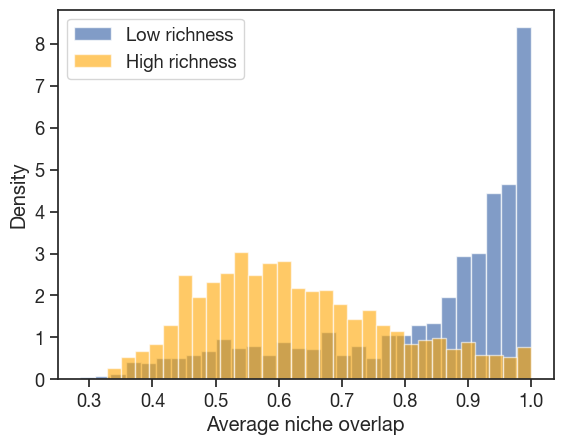

In [124]:
plt.hist(noi_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(noi_rich, bins=30, alpha=0.6, label='High richness', color='orange', density=True)
plt.xlabel('Average niche overlap')
plt.ylabel('Density')
plt.legend()

In [125]:
# Euclidean distance in consumption space
def euclidean_distance_C(C):
    """Compute the average Euclidean distance between species in consumption space."""
    distances = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        dist_ij = np.linalg.norm(ci - cj)
        distances.append(dist_ij)
    return np.mean(distances)

In [126]:
edc_bottom = []
edc_rich = []
for C in C_bottom:
    edc_bottom.append(euclidean_distance_C(C))
for C in C_rich:
    edc_rich.append(euclidean_distance_C(C))



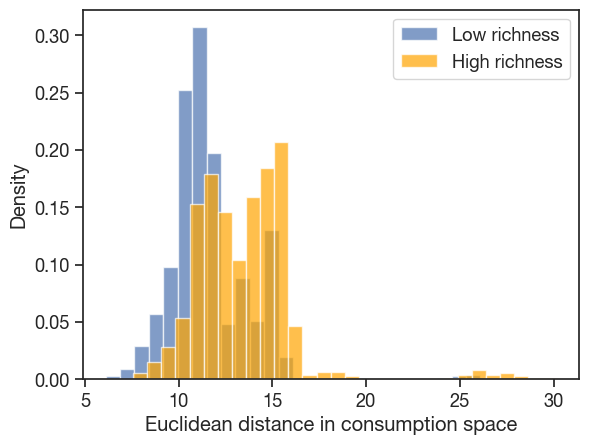

In [127]:
plt.hist(edc_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(edc_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in consumption space')
plt.ylabel('Density')
plt.legend()

# Private niches


In [128]:
(C.astype(bool).sum(axis = 0) == 1).sum()

np.int64(0)

In [129]:
def private_niches(C, fraction=True):
    """Compute the fraction of private niches in a community."""
    if fraction:
        return (C.astype(bool).sum(axis = 0) == 1).sum() / C.shape[1]
    else:
        return (C.astype(bool).sum(axis = 0) == 1).sum()

In [130]:
pn_bottom = []
pn_rich = []
for C in C_bottom:
    pn_bottom.append(private_niches(C, fraction=True))
for C in C_rich:
    pn_rich.append(private_niches(C, fraction=True))

Text(0, 0.5, 'Density')

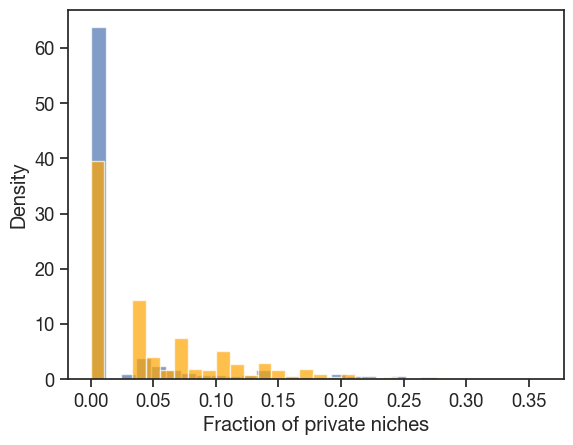

In [131]:
plt.hist(pn_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(pn_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Fraction of private niches')
plt.ylabel('Density')

# Average Km distance

In [132]:
def K_log_eucledian_distance(K):
    distances = []
    S = K.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ki = np.log10(K[i, :])
        kj = np.log10(K[j, :])
        dist_ij = np.linalg.norm(ki - kj)
        distances.append(dist_ij)
    return np.mean(distances)


In [133]:
ked_bottom = []
ked_rich = []
for i in bottom_10:
    K = data[f'K_{i}']
    ked_bottom.append(K_log_eucledian_distance(K))
for i in rich_10:
    K = data[f'K_{i}']
    ked_rich.append(K_log_eucledian_distance(K))

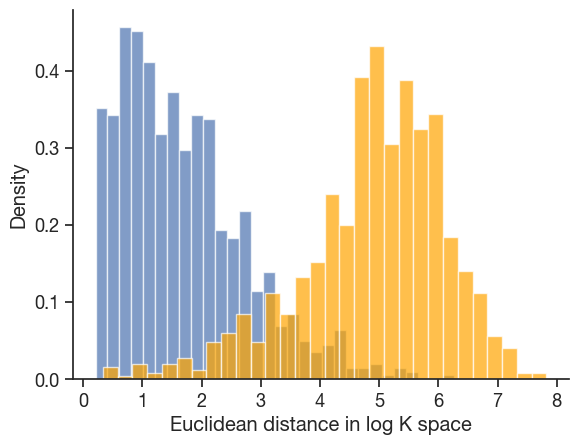

In [166]:
plt.hist(ked_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ked_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log K space')
plt.ylabel('Density')
sns.despine()

# Log K distance and niche overlap

In [172]:
len(list(bottom_10) + list(rich_10))

2000

In [ ]:
plot_df = pd.DataFrame(index = list(bottom_10) + list(rich_10))
plot_df['richness'] = list(mean_richness.loc[bottom_10]) + list(mean_richness.loc[rich_10])
plot_df['noi'] = noi_bottom + noi_rich
plot_df['edc'] = edc_bottom + edc_rich
plot_df['ked'] = ked_bottom + ked_rich
plot_df['Category'] = ['Low richness']*len(bottom_10) + ['High richness']*len(rich_10)


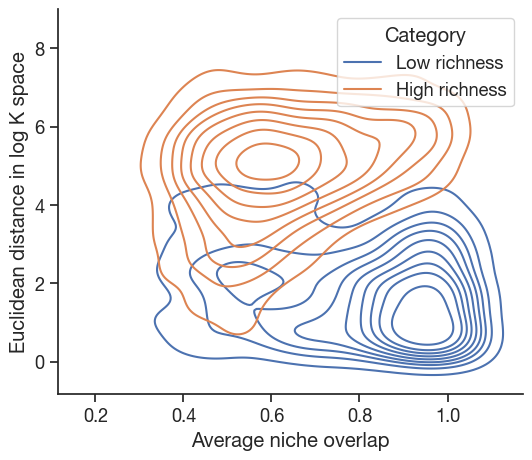

In [179]:
fig, ax = plt.subplots(figsize=(6,5))
sns.kdeplot(data=plot_df, x='noi', y = 'ked', hue = 'Category')
plt.xlabel('Average niche overlap')
plt.ylabel('Euclidean distance in log K space')
sns.despine()

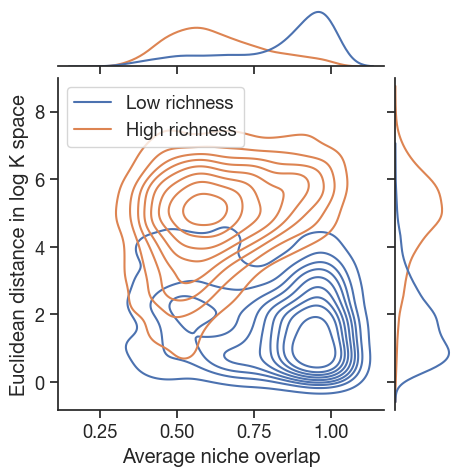

In [189]:
g = sns.jointplot(data=plot_df, x='noi', y='ked', hue='Category', kind='kde', height=5)
g.ax_joint.set_xlabel('Average niche overlap')
g.ax_joint.set_ylabel('Euclidean distance in log K space')
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(0, 1), title='')

In [163]:
def CK_euclidean_distance(CK_ratio):
    distances = []
    S = CK_ratio.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        cki = np.log10(CK_ratio[i, :])
        ckj = np.log10(CK_ratio[j, :])
        # Replace inf with a small number
        cki = np.where(np.isinf(cki), -3, cki)
        ckj = np.where(np.isinf(ckj), -3, ckj)
        
        dist_ij = np.linalg.norm(cki - ckj)
        distances.append(dist_ij)
    return np.mean(distances)

In [148]:
np.log10(0)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56860/135924841.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(0)


np.float64(-inf)

In [164]:
# Perform cell-by-cell division of C on K
ckd_bottom = []
for i in bottom_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_bottom.append(CK_euclidean_distance(CK_ratio))
ckd_rich = []
for i in rich_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_rich.append(CK_euclidean_distance(CK_ratio))

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56860/1167146942.py:5: RuntimeWarning: divide by zero encountered in log10
  cki = np.log10(CK_ratio[i, :])
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56860/1167146942.py:6: RuntimeWarning: divide by zero encountered in log10
  ckj = np.log10(CK_ratio[j, :])


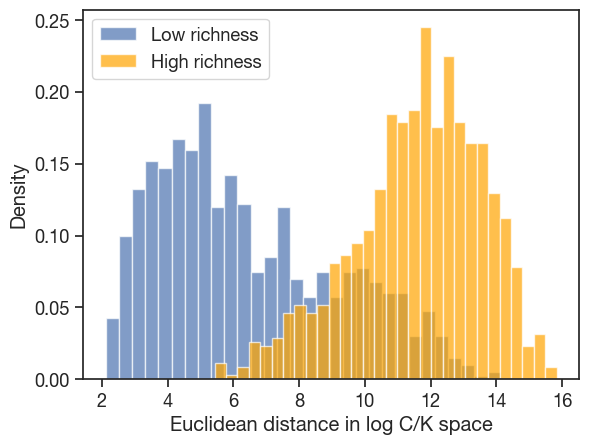

In [165]:
plt.hist(ckd_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ckd_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log C/K space')
plt.ylabel('Density')
plt.legend()

In [161]:
K.max()

np.float64(42.498882092360226)